In [1]:
import stim
import itertools
import numpy as np
import pickle
import time
import os
import re
import pprint
import numpy as np

from autqec.automorphisms   import *
from autqec.utils.qec       import *
from autqec.utils.qiskit    import *
from autqec.graph_auts      import *
from autqec.ZX_dualities    import *
from autqec.ZY_dualities    import *
from autqec.magma_interface import *
from autqec.code_embedding  import *
from magma_online           import *
from stim_helpers           import *
from compare_circuits       import *


In [2]:
generators_5qubits = [
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"),
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZZXIX")
]

# logical operators
logical_I = stim.PauliString("IIIII")
logical_X = stim.PauliString("XXXXX")
logical_Z = stim.PauliString("ZZZZZ")
logical_Y = canonicalize_real_pauli(logical_X * logical_Z)

logical_X_min = stim.PauliString("-YIXIY")
logical_Z_min = stim.PauliString("-XIZIX")
logical_Y_min = canonicalize_real_pauli(logical_X_min * logical_Z_min)

logical_basis5 = {
    "X": canonicalize_real_pauli(logical_X_min),
    "Y": canonicalize_real_pauli(logical_Y_min),
    "Z": canonicalize_real_pauli(logical_Z_min)
}

In [3]:
combined_generators = []
for s in generators_5qubits:
    combined_generators.append(s+logical_I)
    combined_generators.append(logical_I+s)

logical_XI = logical_X_min + logical_I
logical_ZI = logical_Z_min + logical_I
logical_IX = logical_I + logical_X_min
logical_IZ = logical_I + logical_Z_min
logical_XX = logical_X_min + logical_X_min
logical_ZZ = logical_Z_min + logical_Z_min
logical_XZ = logical_X_min + logical_Z_min
logical_ZX = logical_Z_min + logical_X_min
logical_YI = logical_XI * logical_ZI
logical_IY = logical_IX * logical_IZ
logical_YX = logical_YI * logical_IX
logical_YZ = logical_YI * logical_IZ
logical_XY = logical_XI * logical_IY
logical_ZY = logical_ZI * logical_IY
logical_YY = logical_YI * logical_IY

logical_basis = {
    "XI": canonicalize_real_pauli(logical_XI),
    "YI": canonicalize_real_pauli(logical_XI * logical_ZI),
    "ZI": canonicalize_real_pauli(logical_ZI),

    "IX": canonicalize_real_pauli(logical_IX),
    "IY": canonicalize_real_pauli(logical_IX * logical_IZ),
    "IZ": canonicalize_real_pauli(logical_IZ),

    "XX": canonicalize_real_pauli(logical_XI * logical_IX),
    "XY": canonicalize_real_pauli(logical_XI * logical_IY),
    "XZ": canonicalize_real_pauli(logical_XI * logical_IZ),

    "YX": canonicalize_real_pauli(logical_YI * logical_IX),
    "YY": canonicalize_real_pauli(logical_YI * logical_IY),
    "YZ": canonicalize_real_pauli(logical_YI * logical_IZ),

    "ZX": canonicalize_real_pauli(logical_ZI * logical_IX),
    "ZY": canonicalize_real_pauli(logical_ZI * logical_IY),
    "ZZ": canonicalize_real_pauli(logical_ZI * logical_IZ),
}

print_combined_stabilizers(combined_generators, 
                           "Combined generators: two blocks of [[5,1,3]] -> [[10,2,3]]")



Combined generators: two blocks of [[5,1,3]] -> [[10,2,3]]

+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XIXZZIIIII   +IIIIIXIXZZ
+ZZXIXIIIII   +IIIIIZZXIX



In [4]:
prologue = stim.Circuit()
prologue.append("I", [i for i in range(10)])
prologue.append("H", [0])
prologue.append("S", [0])
prologue.append("Y", [2])
prologue.append("H", [4])
prologue.append("S", [4])
prologue.append("H", [5])
prologue.append("S", [5])
prologue.append("Y", [7])
prologue.append("H", [9])
prologue.append("S", [9])
prologue.append("CZ", [0,5])
prologue.append("CZ", [2,7])
prologue.append("CZ", [4,9])
prologue.append("CZ", [0,9])
prologue.append("CZ", [2,5])
prologue.append("CZ", [4,7])
# prologue.append("CZ", [0,7])
# prologue.append("CZ", [2,9])
# prologue.append("CZ", [4,5])

epilogue = stim.Circuit()
epilogue.append("I", [i for i in range(10)])
# epilogue.append("CZ", [2,7])
# epilogue.append("CZ", [4,9])
# epilogue.append("CZ", [0,9])
# epilogue.append("CZ", [2,5])
# epilogue.append("CZ", [4,7])
epilogue.append("CZ", [0,7])
epilogue.append("CZ", [2,9])
epilogue.append("CZ", [4,5])
epilogue.append("S", [0])
epilogue.append("S", [0])
epilogue.append("S", [0])
epilogue.append("H", [0])
epilogue.append("Y", [2])
epilogue.append("S", [4])
epilogue.append("S", [4])
epilogue.append("S", [4])
epilogue.append("H", [4])
epilogue.append("S", [5])
epilogue.append("S", [5])
epilogue.append("S", [5])
epilogue.append("H", [5])
epilogue.append("Y", [7])
epilogue.append("S", [9])
epilogue.append("S", [9])
epilogue.append("S", [9])
epilogue.append("H", [9])

In [5]:
combined_generators_after_prologue = [conjugate_stabilizer_by_circuit(s, prologue) 
                                      for s in combined_generators]
print_combined_stabilizers(combined_generators_after_prologue, 
                            "combined generators after prologue circuit: ")


combined generators after prologue circuit: 

-ZZZXIIIIII   -IIIIIZZZXI
-IXZZZIIIII   -IIIIIIXZZZ
-ZIXZYZIIIZ   -ZIZIIZIXZY
-YZXIZIIZIZ   -ZIIIZYZXIZ



In [6]:
nontrivial_autoqec_circuits = find_nontrivial_autoqec_circuits(
    combined_generators_after_prologue, n=10, k=2, d=3, 
    fileroot="./", verbose=True
)

Run the commands on MAGMA online calculator.
Copy and save output as 'magma_output_n10k2d3.txt'

number of automorphism generators = 5
Circuit (0) [('GammaXYZ', 2), ('GammaXZY', 4), ('GammaXZY', 7), ('GammaXYZ', 9), ('SWAP', (5, 6)), ('SWAP', (4, 9)), ('SWAP', (3, 10)), ('SWAP', (2, 7)), ('SWAP', (1, 8))]
     Logical Action: [('SWAP', (2, 1))]
Circuit (1) [('Z', 3), ('Z', 6), ('Z', 7), ('S', 1), ('H', 2), ('S', 3), ('H', 4), ('S', 5), ('S', 6), ('S', 7), ('S', 8), ('Xsqrt', 9), ('S', 10), ('SWAP', (6, 8)), ('SWAP', (1, 5))]
     Logical Action: [('S', 1), ('S', 2)]
Circuit (2) [('Z', 8), ('S', 6), ('H', 7), ('S', 8), ('H', 9), ('S', 10), ('SWAP', (7, 9))]
     Logical Action: [('S', 2)]
Circuit (3) [('Z', 3), ('S', 1), ('H', 2), ('S', 3), ('H', 4), ('S', 5), ('SWAP', (2, 4))]
     Logical Action: [('S', 1)]


In [7]:
auto_circuit1 = autoqec_to_stim_circuit(nontrivial_autoqec_circuits[0])
auto_circuit1.append("I", [i for i in range(10)])
combined_generators_after_auto_circuit1 = [
    conjugate_stabilizer_by_circuit(s, auto_circuit1)
    for s in combined_generators_after_prologue
]

In [8]:
print_combined_stabilizers(combined_generators_after_prologue, 
                            "combined generators after prologue circuit: ")

print_combined_stabilizers(combined_generators_after_auto_circuit1, 
                            "combined generators after auto_circuit1: ")

print("Check if auto circuit is automorphism of after prologue code:")
span_after_prologue = stabilizer_span(combined_generators_after_prologue)
for g in combined_generators_after_auto_circuit1:
    print(str(g).replace("_", "I"), "YES" if str(g) in span_after_prologue else "NO")


combined generators after prologue circuit: 

-ZZZXIIIIII   -IIIIIZZZXI
-IXZZZIIIII   -IIIIIIXZZZ
-ZIXZYZIIIZ   -ZIZIIZIXZY
-YZXIZIIZIZ   -ZIIIZYZXIZ


combined generators after auto_circuit1: 

-IIIIIIXZZZ   +ZYIYZIIIII
+IIIIIZYIYZ   -ZZZXIIIIII
-IIZIZYIZYX   -XIYXZIIZIZ
-ZIZIIZXYIX   -XYZIYZIZII

Check if auto circuit is automorphism of after prologue code:
-IIIIIIXZZZ YES
+ZYIYZIIIII YES
+IIIIIZYIYZ YES
-ZZZXIIIIII YES
-IIZIZYIZYX YES
-XIYXZIIZIZ NO
-ZIZIIZXYIX NO
-XYZIYZIZII YES


In [9]:
pauli_correction = find_automorphism_pauli_correction(
    auto_gens = combined_generators_after_auto_circuit1,
    orig_gens = combined_generators_after_prologue,
)
print("Pauli correction: ", str(pauli_correction).replace("_", "I"))

corrected_auto_circuit1 = auto_circuit1.copy()
corrected_auto_circuit1 += pauli_to_circuit(pauli_correction)

Pauli correction:  +XIXXIXXIII


In [10]:
combined_generators_after_corrected_auto1 = [conjugate_stabilizer_by_circuit(s, corrected_auto_circuit1) 
                                      for s in combined_generators_after_prologue]

print_combined_stabilizers(combined_generators_after_prologue, 
                            "combined generators after prologue circuit: ")

print_combined_stabilizers(combined_generators_after_corrected_auto1, 
                            "combined generators after corrected auto circuit: ")

print("Check if auto circuit is automorphism of after prologue code:")
span_after_prologue = stabilizer_span(combined_generators_after_prologue)
for g in combined_generators_after_corrected_auto1:
    print(str(g).replace("_", "I"), "YES" if str(g) in span_after_prologue else "NO")



combined generators after prologue circuit: 

-ZZZXIIIIII   -IIIIIZZZXI
-IXZZZIIIII   -IIIIIIXZZZ
-ZIXZYZIIIZ   -ZIZIIZIXZY
-YZXIZIIZIZ   -ZIIIZYZXIZ


combined generators after corrected auto circuit: 

-IIIIIIXZZZ   +ZYIYZIIIII
+IIIIIZYIYZ   -ZZZXIIIIII
-IIZIZYIZYX   +XIYXZIIZIZ
+ZIZIIZXYIX   -XYZIYZIZII

Check if auto circuit is automorphism of after prologue code:
-IIIIIIXZZZ YES
+ZYIYZIIIII YES
+IIIIIZYIYZ YES
-ZZZXIIIIII YES
-IIZIZYIZYX YES
+XIYXZIIZIZ YES
+ZIZIIZXYIX YES
-XYZIYZIZII YES


In [11]:
combined_generators_after_epilogue = [conjugate_stabilizer_by_circuit(s, epilogue) 
                                      for s in combined_generators_after_corrected_auto1]

print_combined_stabilizers(combined_generators, 
                            "original code stabalizors: ")

print_combined_stabilizers(combined_generators_after_epilogue, 
                            "combined generators after epilogue:")

print("Check if same span:")
original_span = stabilizer_span(combined_generators)
for g in combined_generators_after_epilogue:
    print(str(g).replace("_", "I"), "YES" if str(g) in original_span else "NO")



original code stabalizors: 

+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XIXZZIIIII   +IIIIIXIXZZ
+ZZXIXIIIII   +IIIIIZZXIX


combined generators after epilogue:

+IIIIIIXZZX   +XYIYXIIIII
+IIIIIXYIYX   +XZZXIIIIII
+IIIIIZIZYY   +YIYXXIIIII
+IIIIIXXYIY   +YYZIZIIIII

Check if same span:
+IIIIIIXZZX YES
+XYIYXIIIII YES
+IIIIIXYIYX YES
+XZZXIIIIII YES
+IIIIIZIZYY YES
+YIYXXIIIII YES
+IIIIIXXYIY YES
+YYZIZIIIII YES


# Finding Logical Action

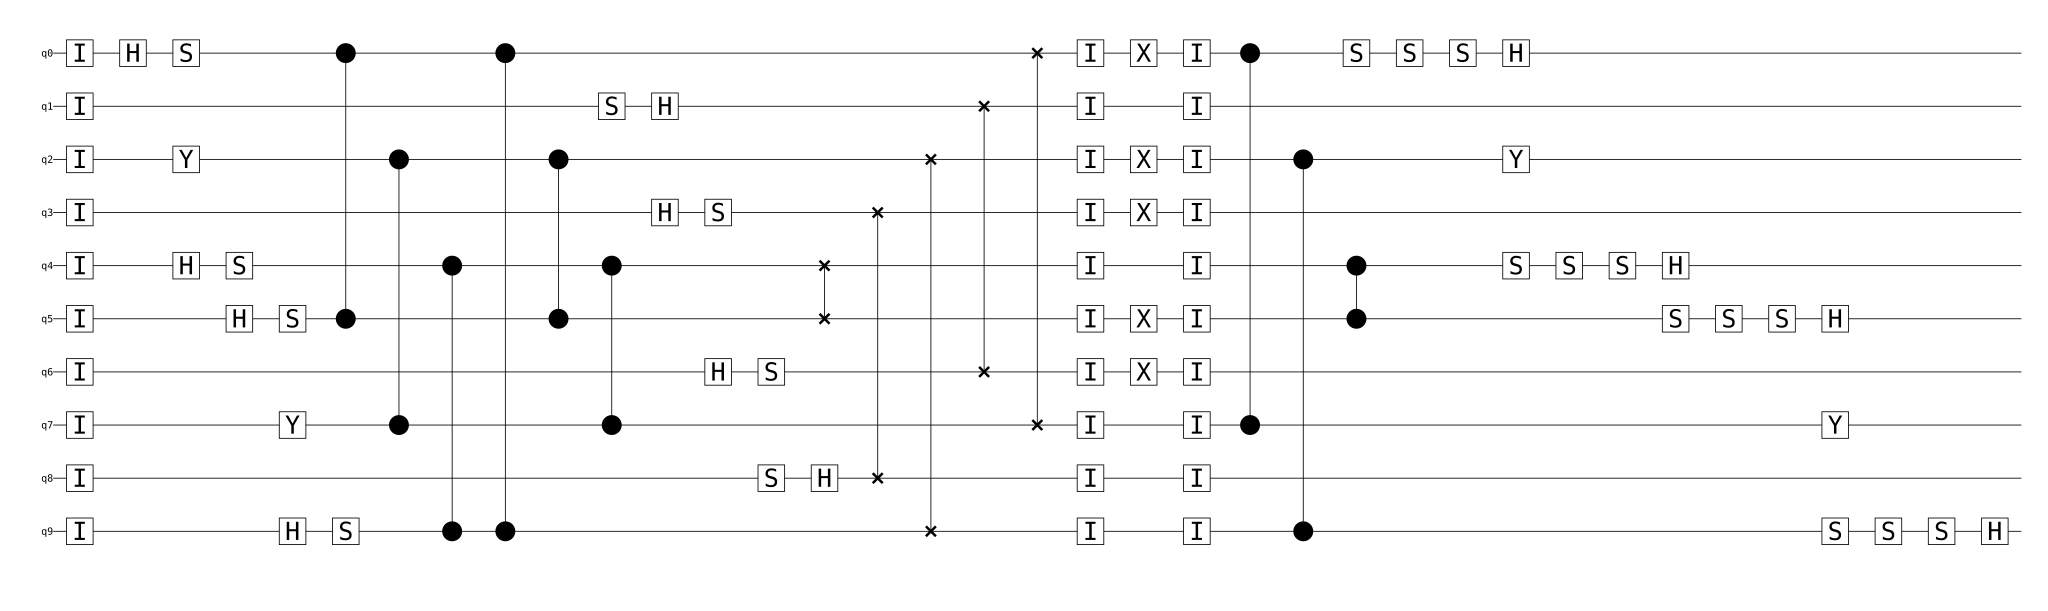

In [12]:
full_circuit = prologue + corrected_auto_circuit1 + epilogue
full_circuit.diagram("timeline-svg")

 Gate        |        before        |        after maps to
     XI      | +YIXIYIIIII            | -ZX
     YI      | +ZIYIZIIIII            | +ZY
     ZI      | +XIZIXIIIII            | -IZ
     IX      | +IIIIIYIXIY            | -XZ
     IY      | +IIIIIZIYIZ            | -YZ
     IZ      | +IIIIIXIZIX            | +ZI
     XX      | +YIXIYYIXIY            | +YY
     XY      | +YIXIYZIYIZ            | -XY
     XZ      | +YIXIYXIZIX            | -IX
     YX      | +ZIYIZYIXIY            | +YX
     YY      | +ZIYIZZIYIZ            | -XX
     YZ      | +ZIYIZXIZIX            | +IY
     ZX      | +XIZIXYIXIY            | +XI
     ZY      | +XIZIXZIYIZ            | +YI
     ZZ      | +XIZIXXIZIX            | -ZZ


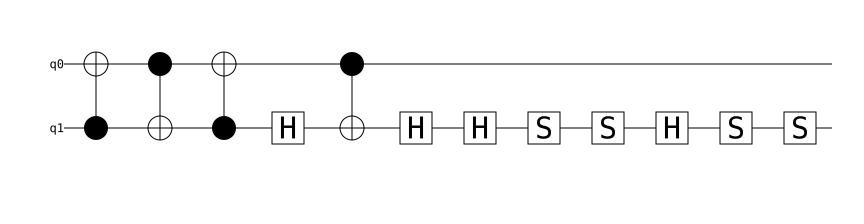

In [13]:
mapping = get_logical_action_map(
    logicals_dict   = logical_basis,
    circuit         = full_circuit,
    stabilizers     = combined_generators_after_epilogue,
    verbose         = True
)

logical_circuit = logical_map_to_tableau_circuit(mapping)
logical_circuit.diagram("timeline-svg")

4


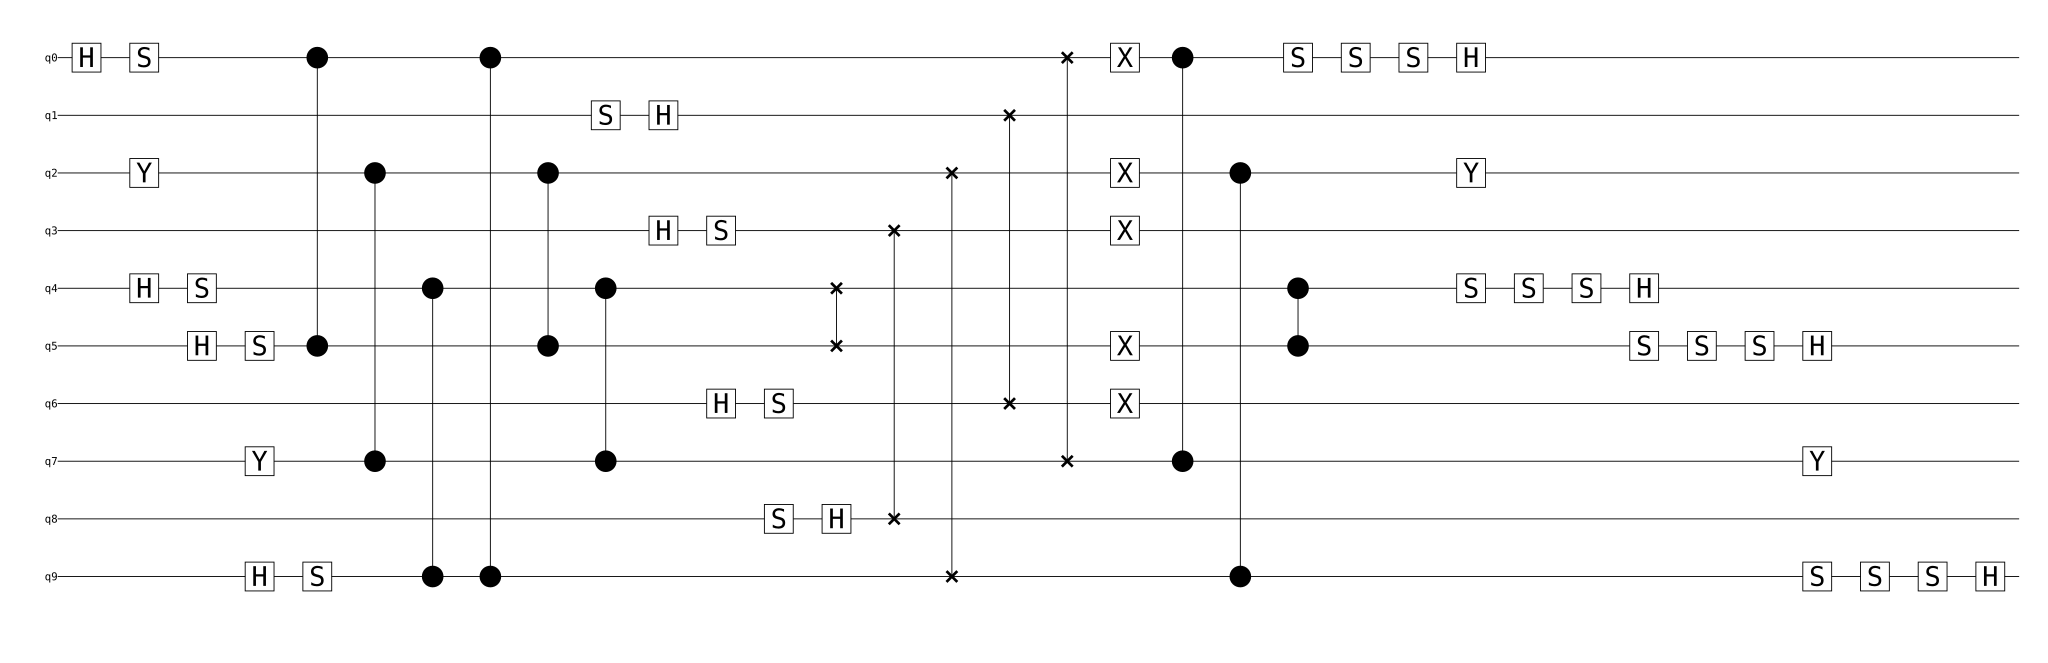

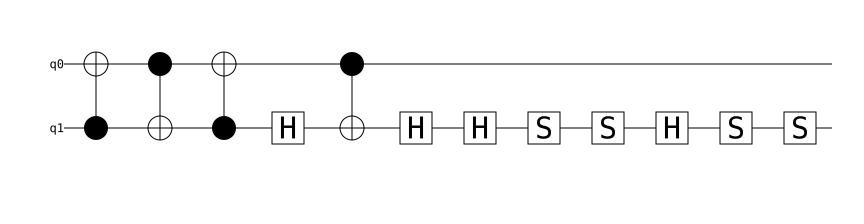

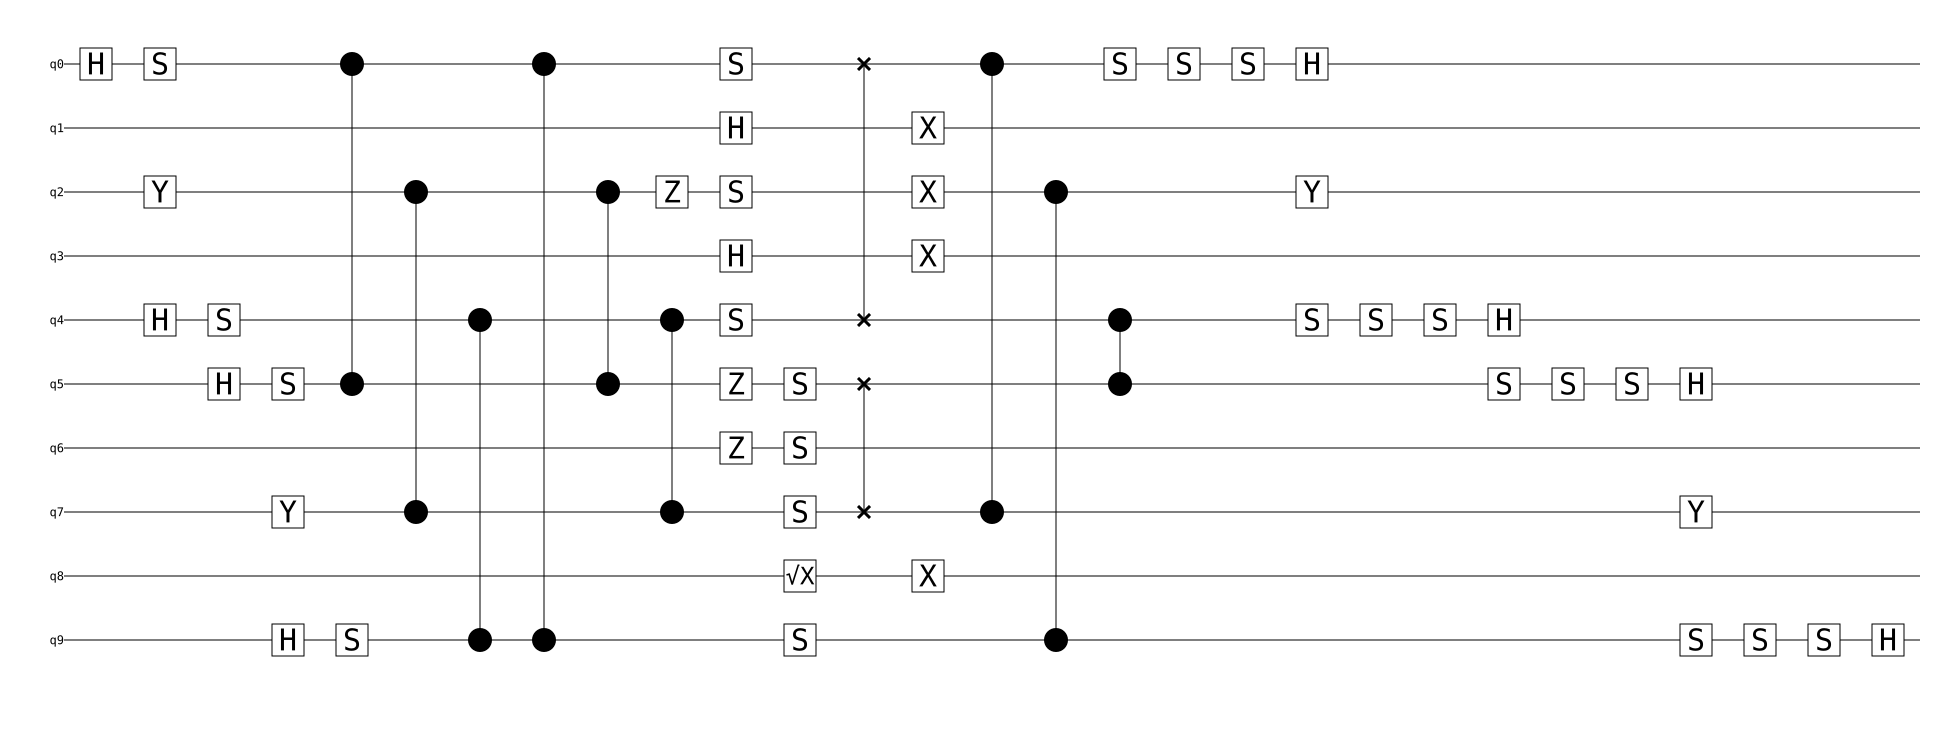

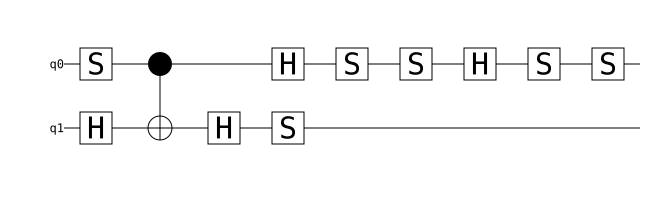

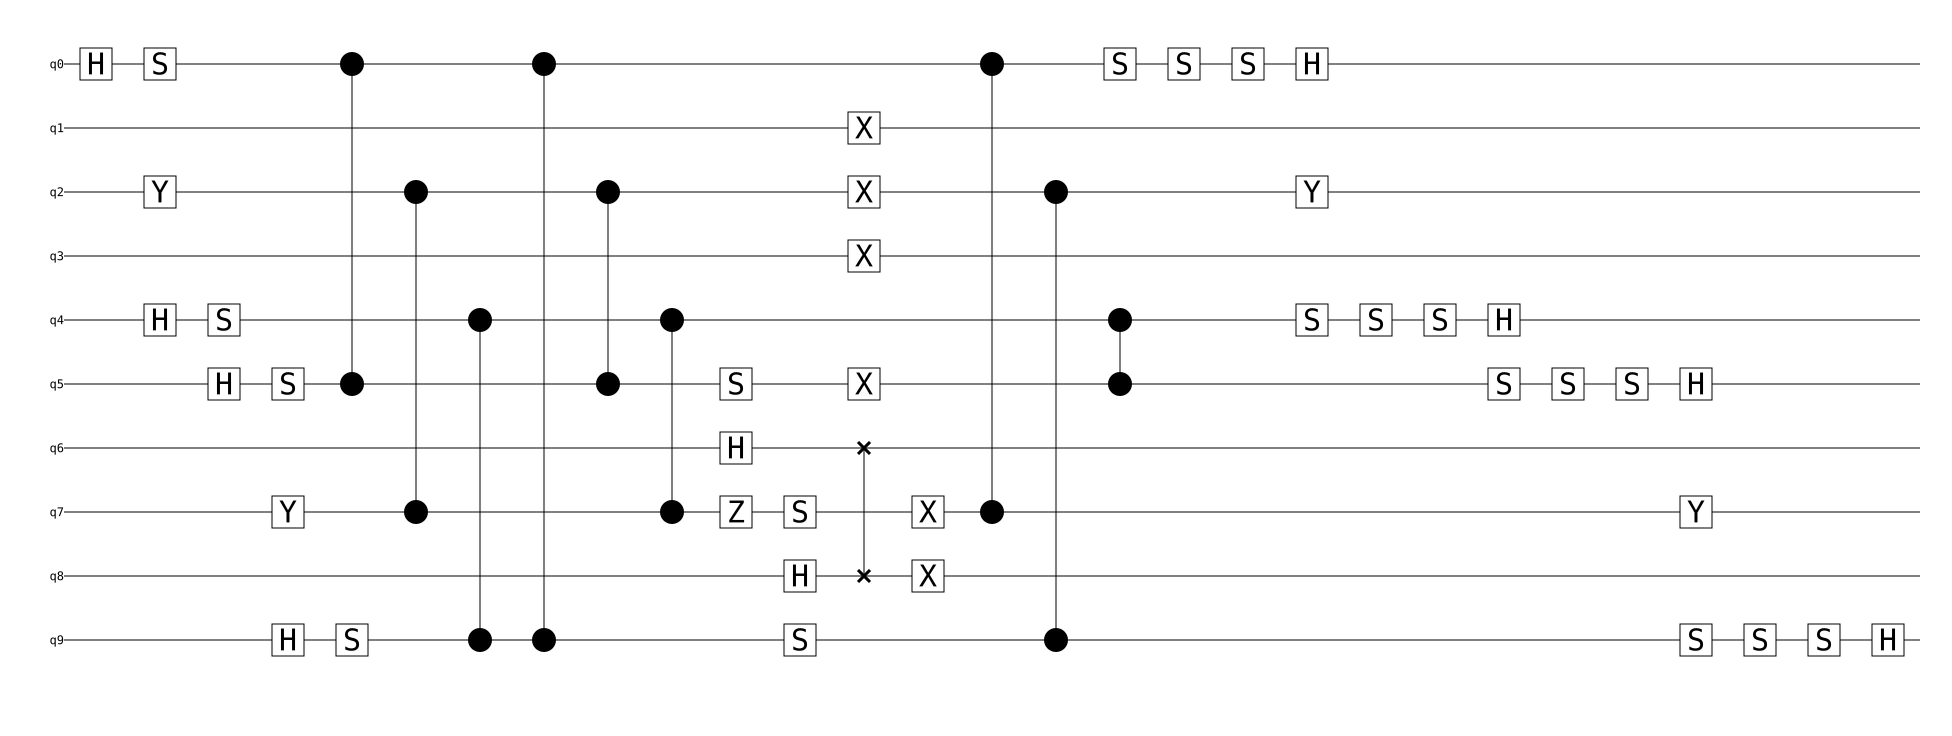

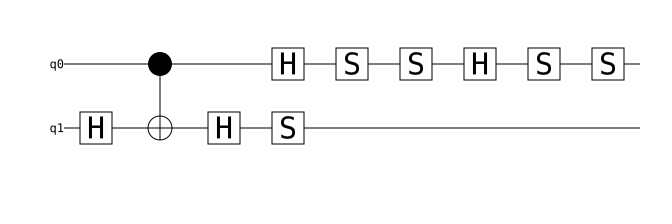

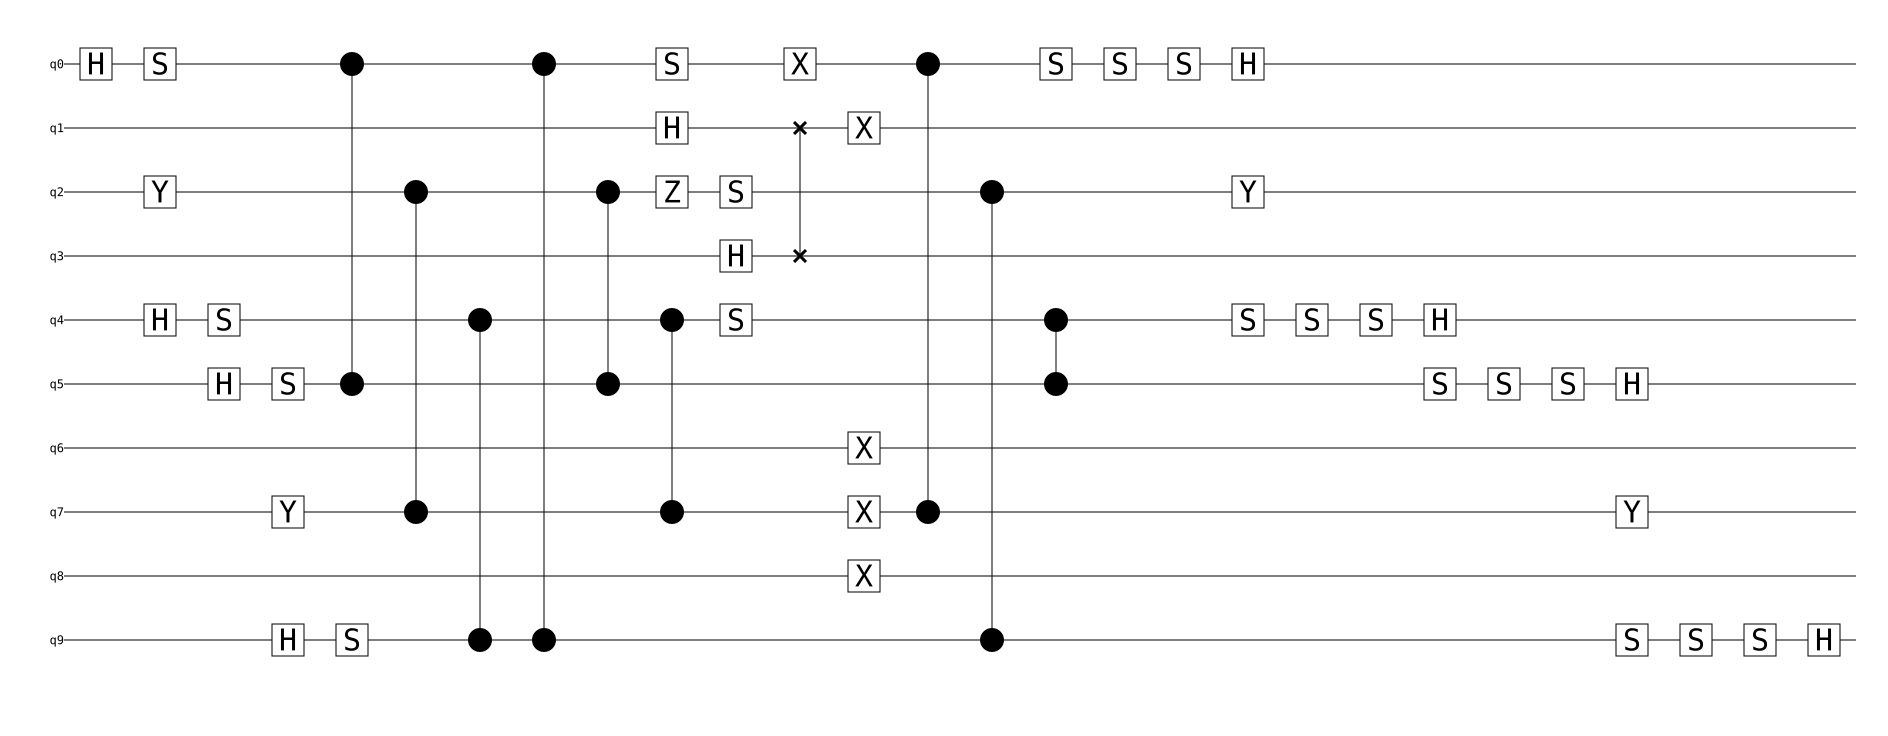

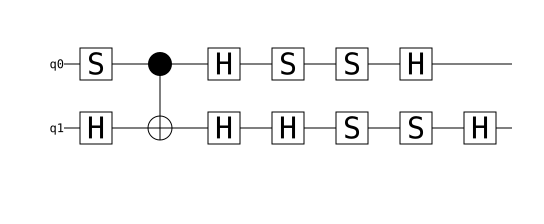

In [14]:
print(len(nontrivial_autoqec_circuits))

physical_circuits_found = []
logical_circuits_found = []

for circ in nontrivial_autoqec_circuits:
    auto_circuit1 = autoqec_to_stim_circuit(circ)
    auto_circuit1.append("I", [i for i in range(10)])

    combined_generators_after_auto = [
        conjugate_stabilizer_by_circuit(s, auto_circuit1)
        for s in combined_generators_after_prologue
    ]

    pauli_correction = find_automorphism_pauli_correction(
        auto_gens = combined_generators_after_auto,
        orig_gens = combined_generators_after_prologue,
    )

    corrected_auto_circuit = auto_circuit1.copy()
    corrected_auto_circuit += pauli_to_circuit(pauli_correction)


    combined_generators_after_corrected_auto = [conjugate_stabilizer_by_circuit(s, corrected_auto_circuit) 
                                        for s in combined_generators_after_prologue]

    combined_generators_after_epilogue = [conjugate_stabilizer_by_circuit(s, epilogue) 
                                        for s in combined_generators_after_corrected_auto]

    full_circuit = remove_identity_gates(prologue + corrected_auto_circuit + epilogue)
    physical_circuits_found.append(full_circuit)
    display(full_circuit.diagram("timeline-svg"))

    mapping = get_logical_action_map(
        logicals_dict   = logical_basis,
        circuit         = full_circuit,
        stabilizers     = combined_generators_after_epilogue
    )

    logical_circuit = logical_map_to_tableau_circuit(mapping)
    logical_circuits_found.append(logical_circuit)
    display(logical_circuit.diagram("timeline-svg"))

Any advantages?
Let's construct the logical circuit from 

<p align="center">
  <img src="H_logical.png" width="300">
  <img src="S_logical.png" width="300">
</p>


In [15]:
# from automorphism on 5-qubit code
H1_logical = [
    ("H", [0]),
    ("Z", [1]),
    ("H", [1]),
    ("Z", [2]),
    ("H", [2]),
    ("H", [3]),
    ("Y", [4]),
    ("H", [4]),
    ("SWAP", [3, 4]),
    ("SWAP", [2, 3]),
    ("SWAP", [1, 3]),

    # logical Y correction
    ("Z", [0]),
    ("Y", [2]),
    ("Z", [4]),
]

S1_logical = [("S", [0]), ("S", [1]), ("S", [2]), ("S", [3]), ("S", [4]),("SWAP", [3,4]), ("SWAP", [2,3]), ("SWAP", [1,3])]
H2_logical = [(gate[0], [q+5 for q in gate[1]]) for gate in H1_logical]
S2_logical = [(gate[0], [q+5 for q in gate[1]]) for gate in S1_logical]

# from peicable FT
CZ_logical = [
            # epilogue
            ("H", [0]),("S", [0]),("Y", [2]),("H", [4]),("S", [4]),
            ("H", [5]),("S", [5]),("Y", [7]),("H", [9]),("S", [9]),
            # roundrobin
            ("CZ", [0,5]),("CZ", [2,7]),("CZ", [4,9]),
            ("CZ", [0,9]),("CZ", [2,5]),("CZ", [4,7]),
            ("CZ", [0,7]),("CZ", [2,9]),("CZ", [4,5]),
            # epilogue
            ("S", [0]),("S", [0]),("S", [0]),("H", [0]),("Y", [2]),
            ("S", [4]),("S", [4]),("S", [4]),("H", [4]),("S", [5]),
            ("S", [5]),("S", [5]),("H", [5]),("Y", [7]),("S", [9]),
            ("S", [9]),("S", [9]),("H", [9]),

            # logical ZZ correction
            ("Z", [i for i in range(10)])
]

confirm there work

In [16]:
H1_logical_circ = stim.Circuit()
for g in H1_logical:
    H1_logical_circ.append(*g)

generators_after_ccccc = [
    conjugate_stabilizer_by_circuit(s, H1_logical_circ)
    for s in generators_5qubits
]

for g in generators_after_ccccc:
    print(str(g).replace("_", "I"))

mapping_H1_logical = get_logical_action_map(
    logicals_dict=logical_basis5,
    circuit=H1_logical_circ,
    stabilizers=generators_5qubits,
    verbose=True,
)


+ZXIXZ
+IXZZX
+ZZXIX
+XZZXI
 Gate        |        before        |        after maps to
     X       | +YIXIY                 | +Z
     Y       | +ZIYIZ                 | -Y
     Z       | +XIZIX                 | +X


In [17]:
S1_logical_circ = stim.Circuit()
for g in S1_logical:
    S1_logical_circ.append(*g)

generators_after_ccccc = [
    conjugate_stabilizer_by_circuit(s, S1_logical_circ)
    for s in generators_5qubits
]

for g in generators_after_ccccc:
    print(str(g).replace("_", "I"))

mapping_manually = get_logical_action_map(
    logicals_dict=logical_basis5,
    circuit=S1_logical_circ,
    stabilizers=generators_5qubits,
    verbose=True,
)

+YZIZY
+IZYYZ
+YYZIZ
+ZYYZI
 Gate        |        before        |        after maps to
     X       | +YIXIY                 | +Y
     Y       | +ZIYIZ                 | -X
     Z       | +XIZIX                 | +Z




+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XIXZZIIIII   +IIIIIXIXZZ
+ZZXIXIIIII   +IIIIIZZXIX

 Gate        |        before        |        after maps to
     XI      | +YIXIYIIIII            | +XZ
     YI      | +ZIYIZIIIII            | +YZ
     ZI      | +XIZIXIIIII            | +ZI
     IX      | +IIIIIYIXIY            | +ZX
     IY      | +IIIIIZIYIZ            | +ZY
     IZ      | +IIIIIXIZIX            | +IZ
     XX      | +YIXIYYIXIY            | +YY
     XY      | +YIXIYZIYIZ            | -YX
     XZ      | +YIXIYXIZIX            | +XI
     YX      | +ZIYIZYIXIY            | -XY
     YY      | +ZIYIZZIYIZ            | +XX
     YZ      | +ZIYIZXIZIX            | +YI
     ZX      | +XIZIXYIXIY            | +IX
     ZY      | +XIZIXZIYIZ            | +IY
     ZZ      | +XIZIXXIZIX            | +ZZ


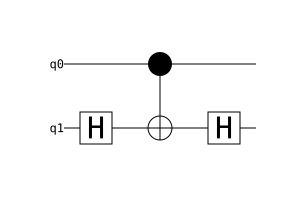

In [18]:
CZ_logical_circ = stim.Circuit()
for g in CZ_logical:
    CZ_logical_circ.append(*g)

generators_after_ccccc = [
    conjugate_stabilizer_by_circuit(s, CZ_logical_circ)
    for s in combined_generators
]

print_combined_stabilizers(generators_after_ccccc)

mapping_manually = get_logical_action_map(
                        logicals_dict   = logical_basis,
                        circuit         = CZ_logical_circ,
                        stabilizers     = combined_generators,
                        verbose         = True,
)
logical_circuit = logical_map_to_tableau_circuit(mapping_manually)
display(logical_circuit.diagram("timeline-svg"))

let's look at the last circuit

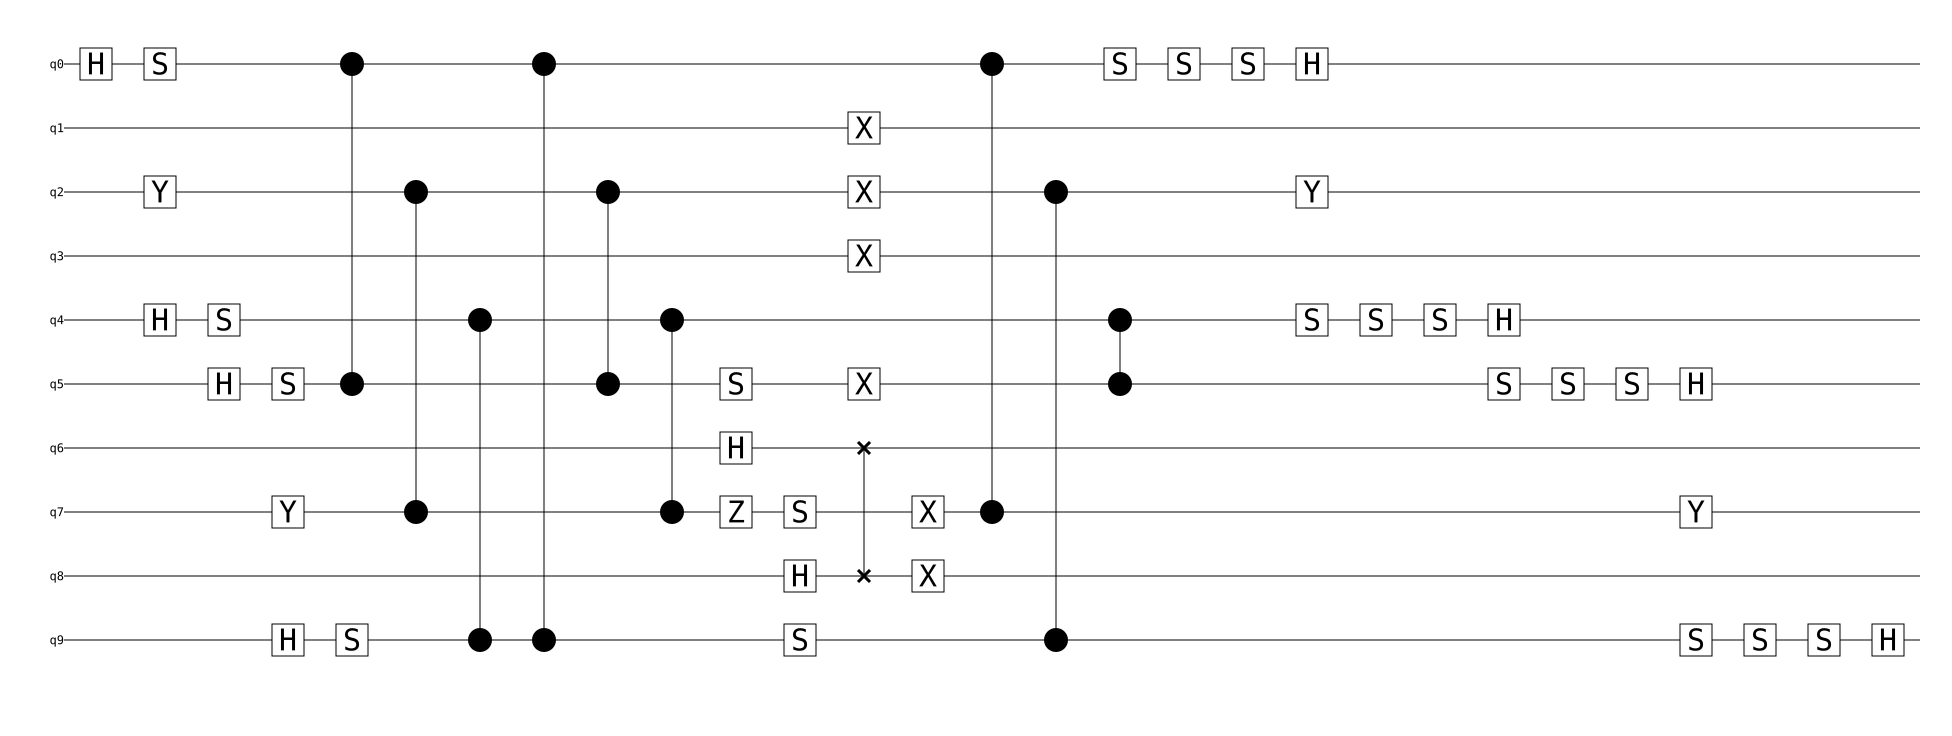

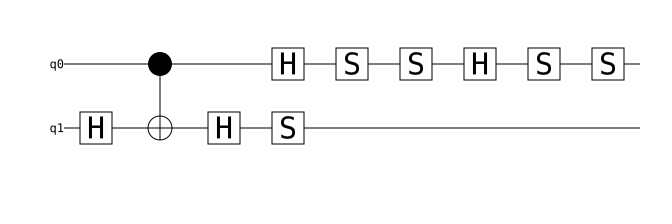

In [23]:
display(physical_circuits_found[-2].diagram("timeline-svg"))
display(logical_circuits_found[-2].diagram("timeline-svg"))

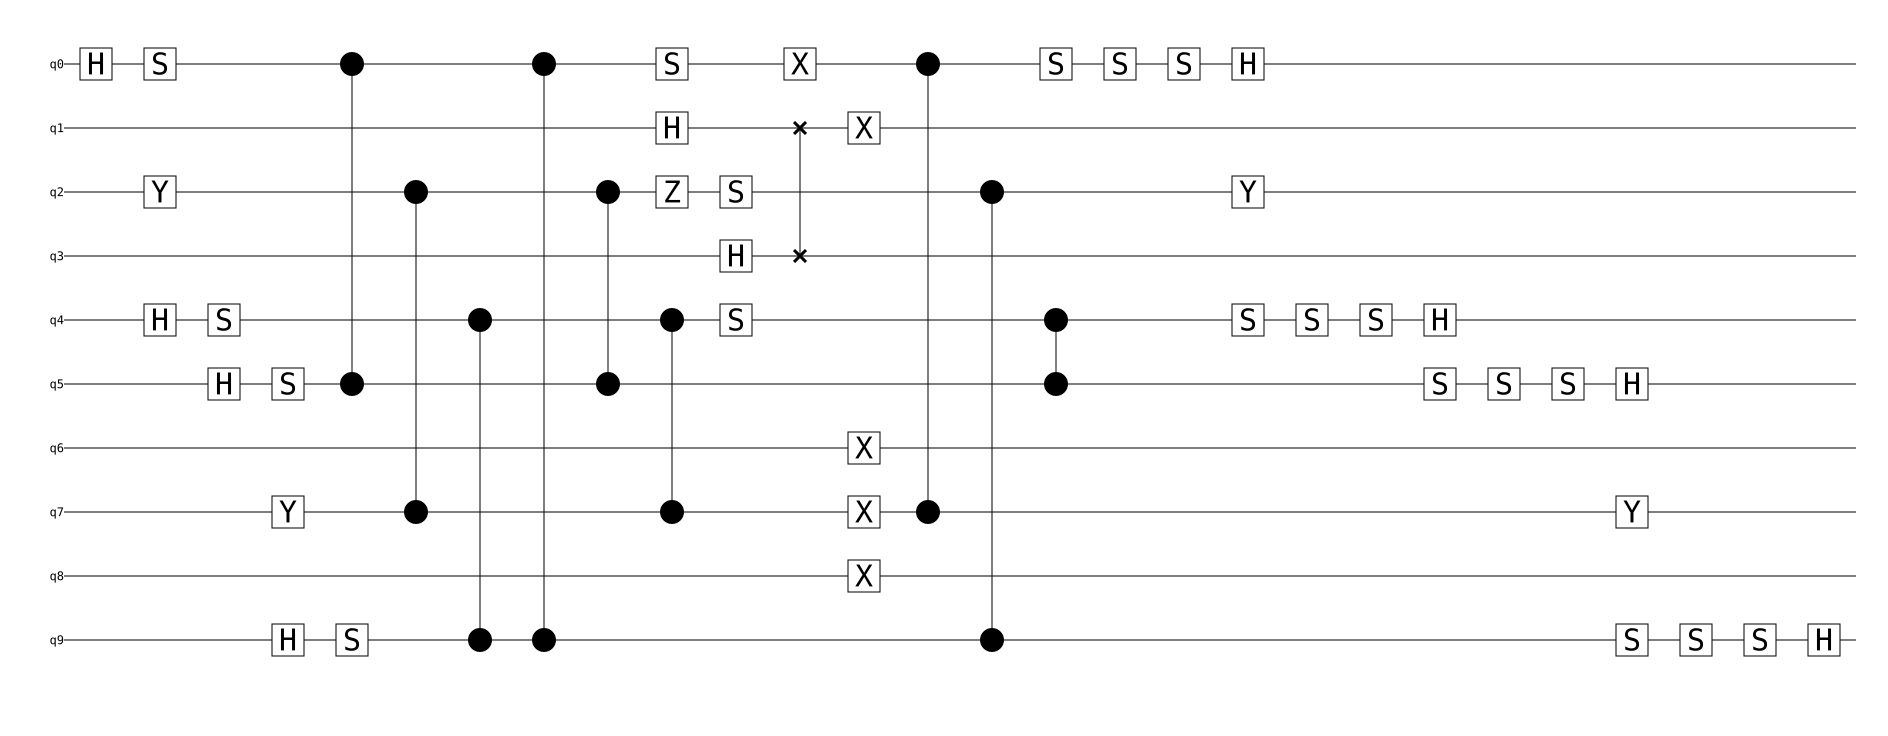

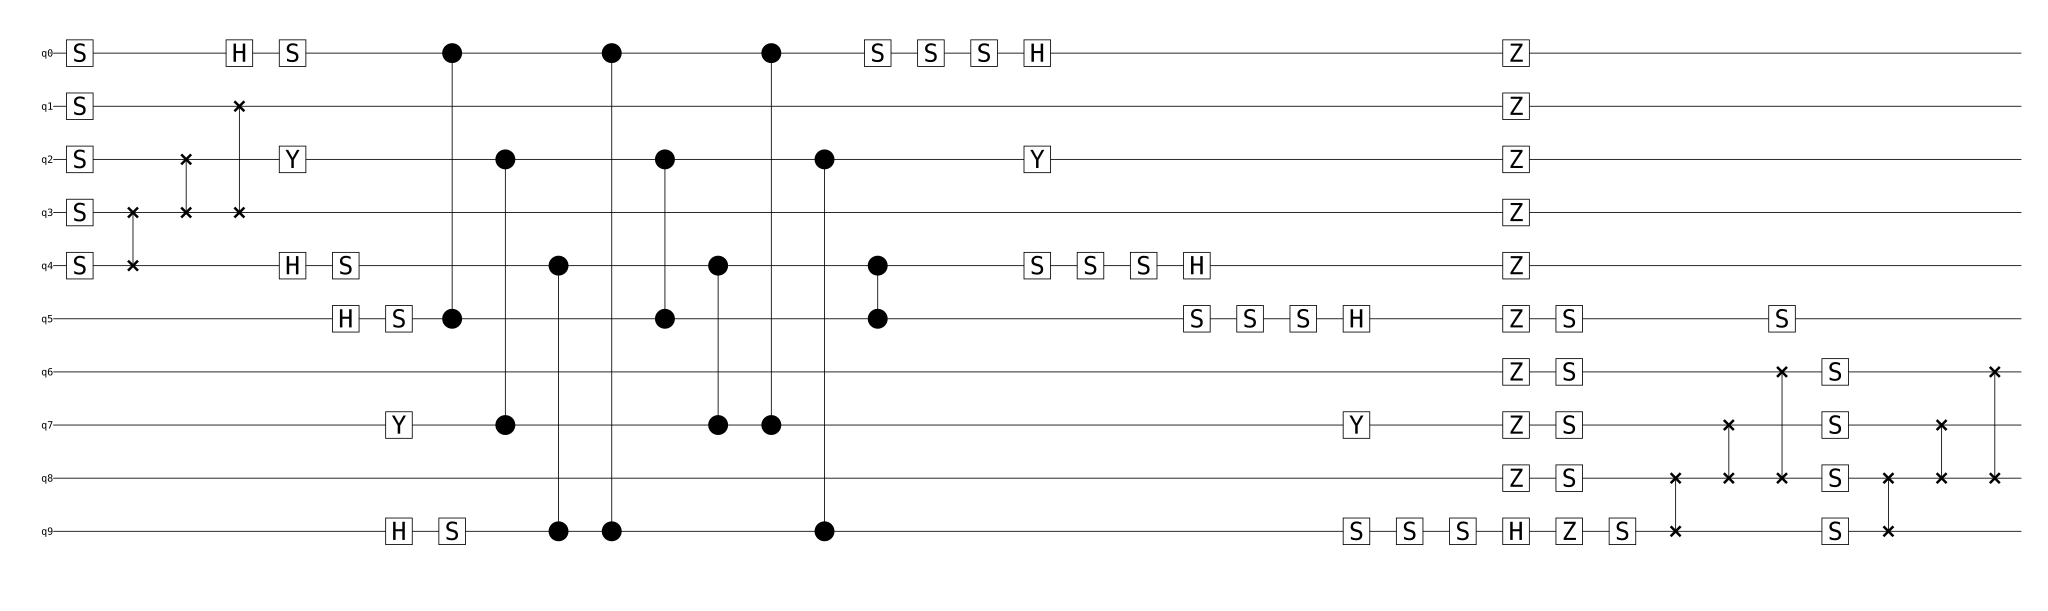

In [20]:
circ_constructed_auto     = physical_circuits_found[-1]
circ_constructed_manually = stim.Circuit()

for g in S1_logical:
    circ_constructed_manually.append(*g)

for g in CZ_logical:
    circ_constructed_manually.append(*g)

for g in S2_logical:
    circ_constructed_manually.append(*g)

for g in S2_logical:
    circ_constructed_manually.append(*g)


display(circ_constructed_auto.diagram("timeline-svg"))
display(circ_constructed_manually.diagram("timeline-svg"))


These two should be equivalent

In [21]:
combined_generators_after_circ_constructed_auto = [conjugate_stabilizer_by_circuit(s, circ_constructed_auto) 
                                    for s in combined_generators]

combined_generators_after_circ_constructed_manually = [conjugate_stabilizer_by_circuit(s, circ_constructed_manually) 
                                    for s in combined_generators]
print_combined_stabilizers(combined_generators)
print_combined_stabilizers(combined_generators_after_circ_constructed_auto)
print_combined_stabilizers(combined_generators_after_circ_constructed_manually)


for g in combined_generators_after_circ_constructed_auto:
    if str(g) not in stabilizer_span(combined_generators):
        print(g, "NO")

for g in combined_generators_after_circ_constructed_manually:
    if str(g) not in stabilizer_span(combined_generators):
        print(g, "NO")

mapping_auto = get_logical_action_map(
    logicals_dict   = logical_basis,
    circuit         = circ_constructed_auto,
    stabilizers     = combined_generators_after_circ_constructed_auto,
    verbose=True
)

mapping_manually = get_logical_action_map(
    logicals_dict   = logical_basis,
    circuit         = circ_constructed_manually,
    stabilizers     = combined_generators_after_circ_constructed_manually,
    verbose=True
)




+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XIXZZIIIII   +IIIIIXIXZZ
+ZZXIXIIIII   +IIIIIZZXIX



+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XXYIYIIIII   +IIIIIXIXZZ
+YIYXXIIIII   +IIIIIZZXIX



+YZIZYIIIII   +IIIIIXIXZZ
+IZYYZIIIII   +IIIIIIXZZX
+YYZIZIIIII   +IIIIIXZZXI
+ZYYZIIIIII   +IIIIIZXIXZ

 Gate        |        before        |        after maps to
     XI      | +YIXIYIIIII            | +YZ
     YI      | +ZIYIZIIIII            | +XZ
     ZI      | +XIZIXIIIII            | -ZI
     IX      | +IIIIIYIXIY            | -ZX
     IY      | +IIIIIZIYIZ            | +ZY
     IZ      | +IIIIIXIZIX            | -IZ
     XX      | +YIXIYYIXIY            | +XY
     XY      | +YIXIYZIYIZ            | +XX
     XZ      | +YIXIYXIZIX            | -YI
     YX      | +ZIYIZYIXIY            | -YY
     YY      | +ZIYIZZIYIZ            | -YX
     YZ      | +ZIYIZXIZIX            | -XI
     ZX      | +XIZIXYIXIY            | +IX
     ZY      | +XIZIXZIYIZ            | -IY
    

Validating 'Circuit Constructed From Automorphism' is Clifford (pre-optimization)...
  ✓ Circuit Constructed From Automorphism is Clifford
Validating 'Circuit Constructed From Combining Logical Operators' is Clifford (pre-optimization)...
  ✓ Circuit Constructed From Combining Logical Operators is Clifford
Validating 'Circuit Constructed From Automorphism' is Clifford (post-optimization)...
  ✓ Circuit Constructed From Automorphism (optimized) is Clifford
Validating 'Circuit Constructed From Combining Logical Operators' is Clifford (post-optimization)...
  ✓ Circuit Constructed From Combining Logical Operators (optimized) is Clifford

  BEFORE -> AFTER OPTIMIZATION
  Metric                Circuit Constructed From Automorphism  Circuit Constructed From Combining Logical Operators
  ────────────────────  ─────────────────────────────────────  ────────────────────────────────────────────────────
  Depth                               11 -> 11                                    20 -> 13 (-7

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/qiskit/compiler/transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


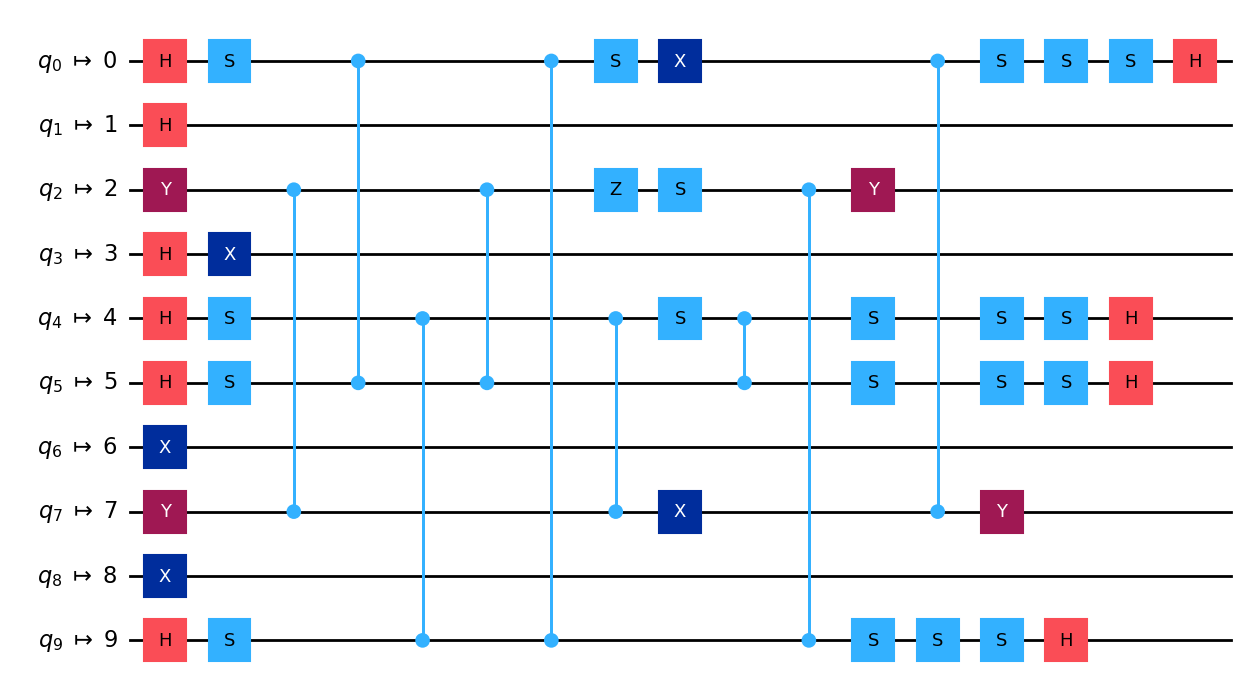

Circuit Constructed From Combining Logical Operators


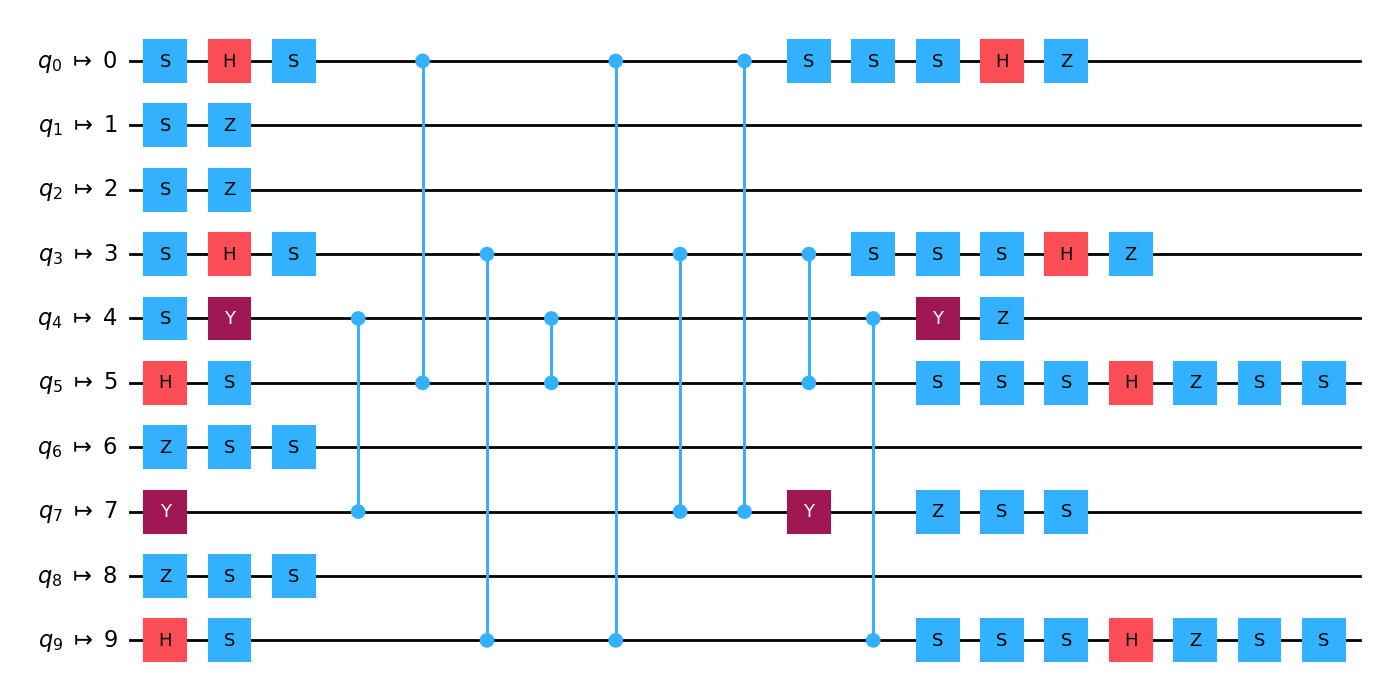

In [22]:
from qiskit.visualization import circuit_drawer

r = compare_circuits(
    circ_constructed_auto,
    circ_constructed_manually,
    name_a= "Circuit Constructed From Automorphism",
    name_b= "Circuit Constructed From Combining Logical Operators",
    optimization_level = 3,
    backend=None
)

print_results(r)


print("Circuit Constructed From Automorphism")
display(circuit_drawer(r["optimized_circuits"]["a"], output="mpl"))
print("Circuit Constructed From Combining Logical Operators")
display(circuit_drawer(r["optimized_circuits"]["b"], output="mpl"))
